# GNN Pass Recipient Prediction

## Using StatsBomb Open Data + 360 Freeze Frames

This notebook builds a **Graph Neural Network (GNN)** to predict the intended recipient of a pass in soccer.

### Approach
For each pass event that has an associated **StatsBomb 360 freeze frame**, we construct a graph where:
- **Nodes** = players visible in the freeze frame at the moment of the pass
- **Edges** = fully connected graph (all players interact)
- **Target** = identify which teammate node received the pass

### Coordinate System
StatsBomb uses a normalized pitch grid of **120 × 80 yards** (center at 60, 40), regardless of actual pitch dimensions.
A standard FIFA soccer pitch is **105m × 68m**. We normalize all coordinates appropriately for the GNN.

| System | Length | Width | Unit |
|---|---|---|---|
| StatsBomb | 120 | 80 | yards |
| Standard FIFA | 105 | 68 | meters |

In [ ]:
# Install dependencies (uncomment if needed)
# !pip install torch torch-geometric matplotlib pandas numpy scikit-learn tqdm

In [10]:
import json
import os
import glob
import math
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Arc
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATConv, GCNConv, global_mean_pool
from sklearn.model_selection import train_test_split

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

PyTorch version: 2.9.1
CUDA available: False
Using device: cpu


## 1. Pitch Dimensions & Coordinate Normalization

StatsBomb maps every pitch to a **120 × 80 yard** coordinate grid:
- X-axis: 0 → 120 (attacking direction, left to right)
- Y-axis: 0 → 80 (bottom to top)
- Center spot: (60, 40)

We provide two normalization strategies:
1. **[0, 1] normalization** — best for neural network input
2. **Meters conversion** — mapping onto a standard 105m × 68m pitch

In [11]:
# === StatsBomb Pitch Dimensions (yards) ===
SB_PITCH_LENGTH = 120.0  # x-axis range
SB_PITCH_WIDTH = 80.0    # y-axis range

# === Standard FIFA Pitch Dimensions (meters) ===
FIFA_PITCH_LENGTH = 105.0
FIFA_PITCH_WIDTH = 68.0


def sb_to_normalized(x: float, y: float) -> tuple[float, float]:
    """Normalize StatsBomb coordinates to [0, 1] range."""
    return x / SB_PITCH_LENGTH, y / SB_PITCH_WIDTH


def sb_to_meters(x: float, y: float) -> tuple[float, float]:
    """Convert StatsBomb coordinates to meters on a standard 105×68m pitch."""
    return x * (FIFA_PITCH_LENGTH / SB_PITCH_LENGTH), y * (FIFA_PITCH_WIDTH / SB_PITCH_WIDTH)


# Verify: center of pitch
print(f"StatsBomb center: (60, 40)")
print(f"Normalized center: {sb_to_normalized(60, 40)}")
print(f"Meters center: {sb_to_meters(60, 40)}")
print(f"\nConversion factors: x * {FIFA_PITCH_LENGTH / SB_PITCH_LENGTH:.4f}, y * {FIFA_PITCH_WIDTH / SB_PITCH_WIDTH:.4f}")

StatsBomb center: (60, 40)
Normalized center: (0.5, 0.5)
Meters center: (52.5, 34.0)

Conversion factors: x * 0.8750, y * 0.8500


## 2. Data Loading

We load:
- **Event files** — contain all match events including passes with origin/end locations and recipient IDs
- **360 files** — contain freeze frames with player positions at the moment of each event

Only matches with both event data **and** 360 data are used (326 matches).

In [12]:
DATA_DIR = os.path.join("..", "data")
EVENTS_DIR = os.path.join(DATA_DIR, "events")
THREE_SIXTY_DIR = os.path.join(DATA_DIR, "three-sixty")

three_sixty_files = sorted(glob.glob(os.path.join(THREE_SIXTY_DIR, "*.json")))
match_ids_with_360 = [os.path.splitext(os.path.basename(f))[0] for f in three_sixty_files]

print(f"Matches with 360 data: {len(match_ids_with_360)}")
print(f"Sample match IDs: {match_ids_with_360[:5]}")

Matches with 360 data: 326
Sample match IDs: ['3788741', '3788742', '3788743', '3788744', '3788745']


In [13]:
def load_match_data(match_id: str) -> tuple[list[dict], dict[str, dict]] | None:
    """Load event and 360 data for a single match, indexing freeze frames by event UUID.
    Returns None if either file is missing or contains malformed JSON."""
    try:
        with open(os.path.join(EVENTS_DIR, f"{match_id}.json")) as f:
            events = json.load(f)
        with open(os.path.join(THREE_SIXTY_DIR, f"{match_id}.json")) as f:
            three_sixty = json.load(f)
    except (json.JSONDecodeError, FileNotFoundError) as e:
        print(f"  Skipping match {match_id}: {e.__class__.__name__}")
        return None

    freeze_frames = {item["event_uuid"]: item for item in three_sixty}
    return events, freeze_frames

## 3. Exploratory Data Analysis

Let's examine the pass events and 360 freeze frames from a sample match.

In [14]:
sample_id = match_ids_with_360[0]
result = load_match_data(sample_id)
while result is None:
    match_ids_with_360.pop(0)
    sample_id = match_ids_with_360[0]
    result = load_match_data(sample_id)
sample_events, sample_frames = result

pass_events = [e for e in sample_events if e.get("type", {}).get("name") == "Pass"]
passes_with_360 = [e for e in pass_events if e["id"] in sample_frames]
passes_with_recipient = [e for e in passes_with_360 if "recipient" in e.get("pass", {})]
completed_passes = [e for e in passes_with_recipient if "outcome" not in e.get("pass", {})]

print(f"Match {sample_id}:")
print(f"  Total events: {len(sample_events)}")
print(f"  Pass events: {len(pass_events)}")
print(f"  Passes with 360 data: {len(passes_with_360)}")
print(f"  Passes with 360 + recipient: {len(passes_with_recipient)}")
print(f"  Completed passes with 360 + recipient: {len(completed_passes)}")

# Examine a sample completed pass (only completed passes have reliable end_location for labeling)
sample_pass = completed_passes[0]
print(f"\n--- Sample Pass ---")
print(f"  Passer: {sample_pass['player']['name']}")
print(f"  Recipient: {sample_pass['pass']['recipient']['name']}")
print(f"  Origin (SB): {sample_pass['location']}")
print(f"  End (SB): {sample_pass['pass']['end_location']}")
origin_m = sb_to_meters(*sample_pass['location'])
end_m = sb_to_meters(*sample_pass['pass']['end_location'])
print(f"  Origin (meters): ({origin_m[0]:.1f}, {origin_m[1]:.1f})")
print(f"  End (meters): ({end_m[0]:.1f}, {end_m[1]:.1f})")

# Examine the freeze frame
frame = sample_frames[sample_pass["id"]]
print(f"\n--- Freeze Frame ---")
print(f"  Players visible: {len(frame['freeze_frame'])}")
for p in frame["freeze_frame"][:5]:
    tag = "[ACTOR]" if p.get("actor") else "[KEEPER]" if p.get("keeper") else ""
    side = "teammate" if p.get("teammate") else "opponent"
    loc_m = sb_to_meters(*p["location"])
    print(f"    {side} {tag}: SB={p['location']} → meters=({loc_m[0]:.1f}, {loc_m[1]:.1f})")

Match 3788741:
  Total events: 3803
  Pass events: 1059
  Passes with 360 data: 907
  Passes with 360 + recipient: 873
  Completed passes with 360 + recipient: 752

--- Sample Pass ---
  Passer: Burak Yılmaz
  Recipient: Caglar Söyüncü
  Origin (SB): [60.0, 40.0]
  End (SB): [32.5, 28.8]
  Origin (meters): (52.5, 34.0)
  End (meters): (28.4, 24.5)

--- Freeze Frame ---
  Players visible: 10
    opponent : SB=[43.65321648946649, 31.98843233703487] → meters=(38.2, 27.2)
    opponent : SB=[43.997359300214555, 45.59948277519069] → meters=(38.5, 38.8)
    opponent : SB=[49.675715677557776, 35.43426789099837] → meters=(43.5, 30.1)
    opponent : SB=[54.49371502803081, 30.093222782354946] → meters=(47.7, 25.6)
    opponent : SB=[58.27928594625963, 48.52844299605966] → meters=(51.0, 41.2)


## 4. Graph Construction

For each pass event with 360 data, we build a **PyTorch Geometric `Data` object**:

### Node Features (per player)
| Feature | Description |
|---|---|
| `x_norm`, `y_norm` | Position normalized to [0, 1] |
| `is_teammate` | 1 if on same team as passer |
| `is_actor` | 1 if this is the passer |
| `is_keeper` | 1 if goalkeeper |
| `dist_to_ball` | Euclidean distance to pass origin (normalized) |
| `angle_to_ball` | Angle to pass origin (radians / π) |

### Edge Construction
- Fully connected graph (every player pair has an edge)

### Target
- Index of the teammate node closest to `pass.end_location` (excluding the passer)

> **Important**: We do NOT include `pass.end_location` as a node feature — that would leak the answer.

In [16]:
NUM_NODE_FEATURES = 7


def build_pass_graph(event: dict, freeze_frame: dict) -> Data | None:
    """
    Build a PyG Data object from a pass event + its 360 freeze frame.

    Returns None if the graph can't be constructed (too few players, no valid recipient, etc.).
    """
    pass_data = event["pass"]
    freeze = freeze_frame.get("freeze_frame", [])

    if len(freeze) < 3:
        return None

    origin_x, origin_y = event["location"]
    end_x, end_y = pass_data["end_location"]

    # Normalize pass origin for feature computation
    ox_n, oy_n = sb_to_normalized(origin_x, origin_y)
    ex_n, ey_n = sb_to_normalized(end_x, end_y)

    node_features = []
    is_candidate = []  # True for teammate non-actor nodes
    min_dist_to_end = float("inf")
    recipient_idx = -1

    for i, player in enumerate(freeze):
        px, py = player["location"]
        px_n, py_n = sb_to_normalized(px, py)

        teammate = float(player.get("teammate", False))
        actor = float(player.get("actor", False))
        keeper = float(player.get("keeper", False))

        dx = px_n - ox_n
        dy = py_n - oy_n
        dist_to_ball = math.sqrt(dx * dx + dy * dy)
        angle_to_ball = math.atan2(dy, dx) / math.pi  # normalize to [-1, 1]

        node_features.append([
            px_n, py_n,
            teammate, actor, keeper,
            dist_to_ball, angle_to_ball,
        ])

        is_candidate_node = bool(teammate) and not bool(player.get("actor", False))
        is_candidate.append(is_candidate_node)

        # Find recipient: teammate closest to pass end location (excluding actor)
        if is_candidate_node:
            dx_end = px_n - ex_n
            dy_end = py_n - ey_n
            dist_to_end = math.sqrt(dx_end * dx_end + dy_end * dy_end)
            if dist_to_end < min_dist_to_end:
                min_dist_to_end = dist_to_end
                recipient_idx = i

    if recipient_idx == -1:
        return None

    n = len(freeze)

    # Fully connected edges
    src = [i for i in range(n) for j in range(n) if i != j]
    dst = [j for i in range(n) for j in range(n) if i != j]

    x = torch.tensor(node_features, dtype=torch.float)
    edge_index = torch.tensor([src, dst], dtype=torch.long)
    candidate_mask = torch.tensor(is_candidate, dtype=torch.bool)
    y = torch.tensor(recipient_idx, dtype=torch.long)

    data = Data(x=x, edge_index=edge_index, y=y)
    data.candidate_mask = candidate_mask
    data.num_candidates = int(candidate_mask.sum().item())
    data.pass_outcome = pass_data.get("outcome", {}).get("name", "Complete")

    return data

## 5. Build Dataset from All 360 Matches

In [17]:
all_graphs = []
stats = defaultdict(int)

for match_id in tqdm(match_ids_with_360, desc="Processing matches"):
    result = load_match_data(match_id)
    if result is None:
        stats["bad_json"] += 1
        continue
    events, freeze_frames = result

    for event in events:
        if event.get("type", {}).get("name") != "Pass":
            continue
        if "pass" not in event or "recipient" not in event["pass"]:
            stats["no_recipient"] += 1
            continue
        # Filter out incomplete passes — their end_location doesn't reflect the intended recipient
        if "outcome" in event["pass"]:
            stats["incomplete"] += 1
            continue
        if event["id"] not in freeze_frames:
            stats["no_360"] += 1
            continue

        graph = build_pass_graph(event, freeze_frames[event["id"]])
        if graph is not None:
            all_graphs.append(graph)
            stats["success"] += 1
        else:
            stats["build_failed"] += 1

print(f"\n=== Dataset Statistics ===")
print(f"Graphs built successfully: {stats['success']:,}")
print(f"Passes without recipient: {stats['no_recipient']:,}")
print(f"Incomplete passes filtered: {stats['incomplete']:,}")
print(f"Passes without 360 data: {stats['no_360']:,}")
print(f"Graph build failures: {stats['build_failed']:,}")
print(f"Matches skipped (bad JSON): {stats['bad_json']:,}")
print(f"\nTotal graphs (completed passes only): {len(all_graphs):,}")

Processing matches:  22%|██▏       | 72/326 [00:09<00:26,  9.66it/s]

  Skipping match 3835338: JSONDecodeError


Processing matches:  23%|██▎       | 76/326 [00:10<00:24, 10.11it/s]

  Skipping match 3835342: JSONDecodeError


Processing matches:  25%|██▍       | 81/326 [00:10<00:27,  8.94it/s]

  Skipping match 3845506: JSONDecodeError


Processing matches: 100%|██████████| 326/326 [00:45<00:00,  7.12it/s]


=== Dataset Statistics ===
Graphs built successfully: 227,513
Passes without recipient: 20,557
Incomplete passes filtered: 43,455
Passes without 360 data: 40,309
Graph build failures: 148
Matches skipped (bad JSON): 3

Total graphs (completed passes only): 227,513


In [18]:
# Dataset summary
num_nodes_list = [g.x.size(0) for g in all_graphs]
num_candidates_list = [g.num_candidates for g in all_graphs]
outcomes = [g.pass_outcome for g in all_graphs]

print(f"Nodes per graph — min: {min(num_nodes_list)}, max: {max(num_nodes_list)}, "
      f"mean: {np.mean(num_nodes_list):.1f}, median: {np.median(num_nodes_list):.0f}")
print(f"Candidates per graph — min: {min(num_candidates_list)}, max: {max(num_candidates_list)}, "
      f"mean: {np.mean(num_candidates_list):.1f}")

outcome_counts = pd.Series(outcomes).value_counts()
print(f"\nPass outcomes:")
for outcome, count in outcome_counts.items():
    print(f"  {outcome}: {count:,} ({100 * count / len(outcomes):.1f}%)")

Nodes per graph — min: 3, max: 22, mean: 15.3, median: 16
Candidates per graph — min: 1, max: 10, mean: 6.6

Pass outcomes:
  Complete: 227,513 (100.0%)


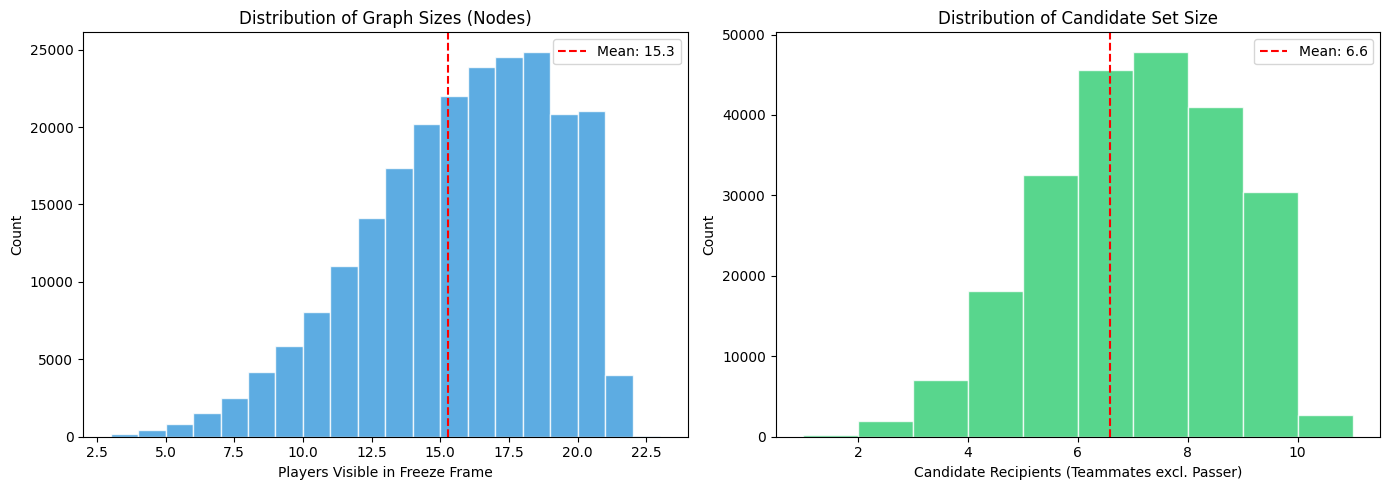

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(num_nodes_list, bins=range(3, max(num_nodes_list) + 2), color='#3498db', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Players Visible in Freeze Frame')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Graph Sizes (Nodes)')
axes[0].axvline(np.mean(num_nodes_list), color='red', linestyle='--', label=f'Mean: {np.mean(num_nodes_list):.1f}')
axes[0].legend()

axes[1].hist(num_candidates_list, bins=range(1, max(num_candidates_list) + 2), color='#2ecc71', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Candidate Recipients (Teammates excl. Passer)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Candidate Set Size')
axes[1].axvline(np.mean(num_candidates_list), color='red', linestyle='--', label=f'Mean: {np.mean(num_candidates_list):.1f}')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Train/Validation/Test Split

In [20]:
train_graphs, test_graphs = train_test_split(all_graphs, test_size=0.15, random_state=42)
train_graphs, val_graphs = train_test_split(train_graphs, test_size=0.15 / 0.85, random_state=42)

print(f"Train: {len(train_graphs):,}")
print(f"Val:   {len(val_graphs):,}")
print(f"Test:  {len(test_graphs):,}")

BATCH_SIZE = 512
train_loader = DataLoader(train_graphs, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_graphs, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_graphs, batch_size=BATCH_SIZE, shuffle=False)

Train: 159,259
Val:   34,127
Test:  34,127


## 7. GNN Model — Graph Attention Network (GAT)

Architecture:
1. **2× GAT layers** with multi-head attention to learn player interaction patterns
2. **Scoring head** produces a scalar score per node
3. At inference, scores are **masked to candidate teammates only**, then softmaxed
4. Loss: **cross-entropy** over the candidate set (pointer-style selection)

In [21]:
class PassRecipientGAT(nn.Module):
    """GAT with residual connections and batch norm to prevent over-smoothing
    on fully-connected graphs."""

    def __init__(self, in_channels: int, hidden_channels: int = 64, heads: int = 4, dropout: float = 0.2):
        super().__init__()
        self.input_proj = nn.Linear(in_channels, hidden_channels)
        self.gat1 = GATConv(hidden_channels, hidden_channels, heads=heads, concat=False, dropout=dropout)
        self.bn1 = nn.BatchNorm1d(hidden_channels)
        self.gat2 = GATConv(hidden_channels, hidden_channels, heads=heads, concat=False, dropout=dropout)
        self.bn2 = nn.BatchNorm1d(hidden_channels)
        self.score_head = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels // 2, 1),
        )
        self.dropout = dropout

    def forward(self, x, edge_index):
        h = F.elu(self.input_proj(x))

        # GAT block 1 + residual
        h = h + F.dropout(F.elu(self.bn1(self.gat1(h, edge_index))),
                          p=self.dropout, training=self.training)
        # GAT block 2 + residual
        h = h + F.dropout(F.elu(self.bn2(self.gat2(h, edge_index))),
                          p=self.dropout, training=self.training)

        return self.score_head(h).squeeze(-1)

In [22]:
from torch_geometric.utils import softmax as pyg_softmax

NEG_INF = float("-inf")


def compute_loss(scores: torch.Tensor, batch) -> torch.Tensor:
    """Vectorized cross-entropy loss over candidate sets.

    Uses torch.where (not in-place assignment) so autograd
    can propagate gradients cleanly through candidate scores.
    """
    masked = torch.where(
        batch.candidate_mask,
        scores,
        torch.tensor(NEG_INF, device=scores.device),
    )

    probs = pyg_softmax(masked, batch.batch)

    global_targets = batch.ptr[:-1] + batch.y
    valid = batch.candidate_mask[global_targets]

    if valid.sum() == 0:
        return torch.tensor(0.0, device=scores.device, requires_grad=True)

    return -torch.log(probs[global_targets][valid] + 1e-8).mean()


def compute_top1(scores: torch.Tensor, batch) -> tuple[int, int]:
    """Top-1 accuracy using per-graph argmax via batch.ptr segments."""
    with torch.no_grad():
        masked = torch.where(
            batch.candidate_mask,
            scores,
            torch.tensor(NEG_INF, device=scores.device),
        )

        global_targets = batch.ptr[:-1] + batch.y
        valid = batch.candidate_mask[global_targets]

        if valid.sum() == 0:
            return 0, 0

        correct = 0
        total = 0
        for g in range(batch.num_graphs):
            if not valid[g]:
                continue
            start = batch.ptr[g].item()
            end = batch.ptr[g + 1].item()
            predicted_global = start + masked[start:end].argmax().item()
            if predicted_global == global_targets[g].item():
                correct += 1
            total += 1

        return correct, total

## 8. Training Loop

In [23]:
model = PassRecipientGAT(
    in_channels=NUM_NODE_FEATURES,
    hidden_channels=64,
    heads=4,
    dropout=0.2,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {total_params:,} (trainable: {trainable_params:,})")
print(model)

Model parameters: 36,801 (trainable: 36,801)
PassRecipientGAT(
  (input_proj): Linear(in_features=7, out_features=64, bias=True)
  (gat1): GATConv(64, 64, heads=4)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (gat2): GATConv(64, 64, heads=4)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (score_head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [24]:
import time

NUM_EPOCHS = 15
PATIENCE = 5

history = {"train_loss": [], "val_loss": [], "val_top1": []}
best_val_loss = float("inf")
patience_counter = 0

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    # --- Train (loss only, no accuracy computation) ---
    model.train()
    epoch_loss = 0.0
    n_batches = 0

    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        scores = model(batch.x, batch.edge_index)
        loss = compute_loss(scores, batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item()
        n_batches += 1

    train_loss = epoch_loss / n_batches

    # --- Validate ---
    model.eval()
    val_loss_sum = 0.0
    val_top1 = 0
    val_total = 0
    val_batches = 0

    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            scores = model(batch.x, batch.edge_index)
            val_loss_sum += compute_loss(scores, batch).item()
            val_batches += 1
            t1, t = compute_top1(scores, batch)
            val_top1 += t1
            val_total += t

    val_loss = val_loss_sum / val_batches
    val_acc1 = val_top1 / max(val_total, 1)

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_top1"].append(val_acc1)

    elapsed = time.time() - t0
    lr = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch:2d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} Top1: {val_acc1:.3f} | "
          f"LR: {lr:.2e} | {elapsed:.1f}s")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}")
            break

model.load_state_dict(best_state)
print(f"\nBest validation loss: {best_val_loss:.4f}")

Epoch  1/15 | Train Loss: 1.5784 | Val Loss: 1.4395 Top1: 0.425 | LR: 1.00e-03 | 62.8s
Epoch  2/15 | Train Loss: 1.4648 | Val Loss: 1.4172 Top1: 0.437 | LR: 1.00e-03 | 64.5s
Epoch  3/15 | Train Loss: 1.4403 | Val Loss: 1.3853 Top1: 0.453 | LR: 1.00e-03 | 63.7s
Epoch  4/15 | Train Loss: 1.4246 | Val Loss: 1.3764 Top1: 0.460 | LR: 1.00e-03 | 64.3s
Epoch  5/15 | Train Loss: 1.4154 | Val Loss: 1.3681 Top1: 0.464 | LR: 1.00e-03 | 65.2s
Epoch  6/15 | Train Loss: 1.4085 | Val Loss: 1.3586 Top1: 0.466 | LR: 1.00e-03 | 67.5s
Epoch  7/15 | Train Loss: 1.4014 | Val Loss: 1.3542 Top1: 0.472 | LR: 1.00e-03 | 66.3s
Epoch  8/15 | Train Loss: 1.3994 | Val Loss: 1.3497 Top1: 0.473 | LR: 1.00e-03 | 65.3s
Epoch  9/15 | Train Loss: 1.3947 | Val Loss: 1.3471 Top1: 0.476 | LR: 1.00e-03 | 65.4s
Epoch 10/15 | Train Loss: 1.3939 | Val Loss: 1.3464 Top1: 0.475 | LR: 1.00e-03 | 64.1s
Epoch 11/15 | Train Loss: 1.3886 | Val Loss: 1.3502 Top1: 0.475 | LR: 1.00e-03 | 64.9s
Epoch 12/15 | Train Loss: 1.3898 | Val Loss

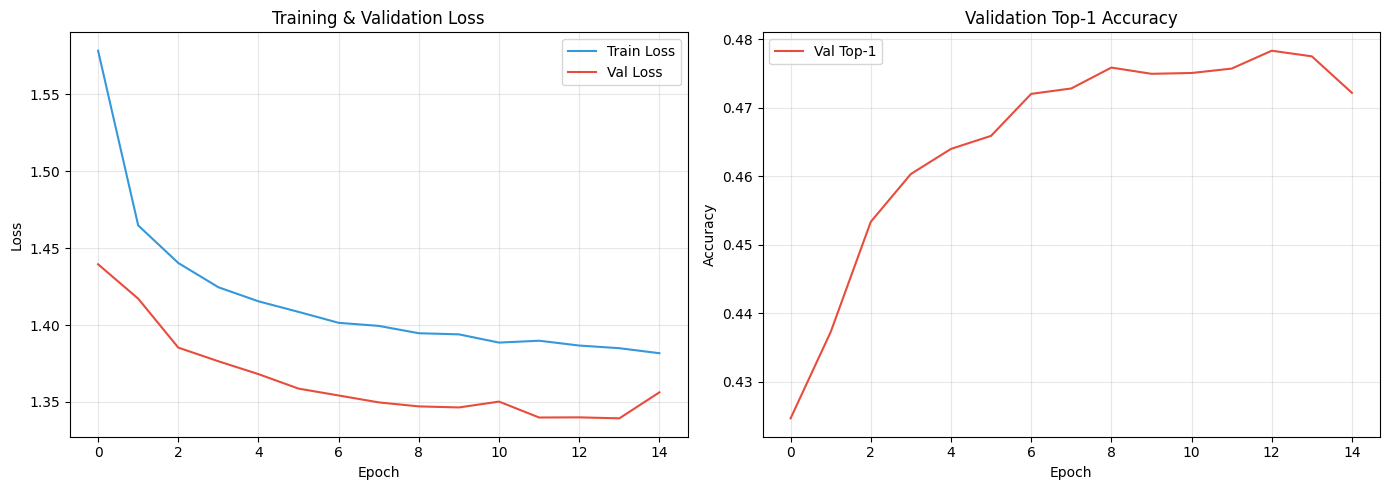

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history["train_loss"], label="Train Loss", color='#3498db')
axes[0].plot(history["val_loss"], label="Val Loss", color='#e74c3c')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training & Validation Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history["val_top1"], label="Val Top-1", color='#e74c3c')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Validation Top-1 Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Test Set Evaluation

In [26]:
model.eval()
test_top1 = 0
test_total = 0
random_baseline_sum = 0.0

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        scores = model(batch.x, batch.edge_index)
        t1, t = compute_top1(scores, batch)
        test_top1 += t1
        test_total += t

for g in test_graphs:
    if g.num_candidates >= 2:
        random_baseline_sum += 1.0 / g.num_candidates

test_acc1 = test_top1 / max(test_total, 1)
random_baseline = random_baseline_sum / max(test_total, 1)

print(f"=== Test Set Results ===")
print(f"Samples evaluated: {test_total:,}")
print(f"")
print(f"Random Baseline Top-1: {random_baseline:.3f} ({100*random_baseline:.1f}%)")
print(f"GNN Top-1 Accuracy:    {test_acc1:.3f} ({100*test_acc1:.1f}%)")
print(f"")
print(f"Lift over random (Top-1): {test_acc1 / max(random_baseline, 1e-9):.2f}x")

=== Test Set Results ===
Samples evaluated: 34,127

Random Baseline Top-1: 0.165 (16.5%)
GNN Top-1 Accuracy:    0.474 (47.4%)

Lift over random (Top-1): 2.87x


## 10. Qualitative Analysis — Visualize Predictions

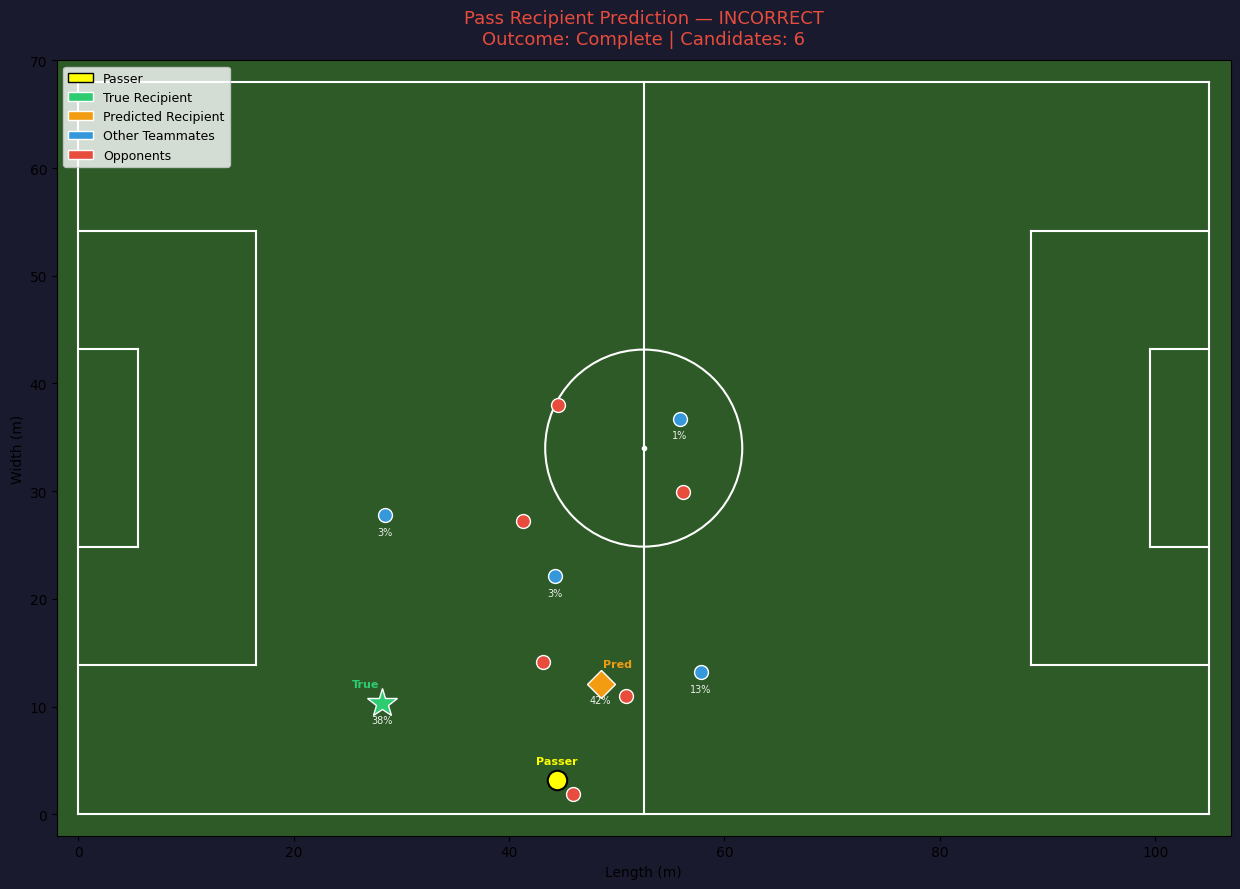

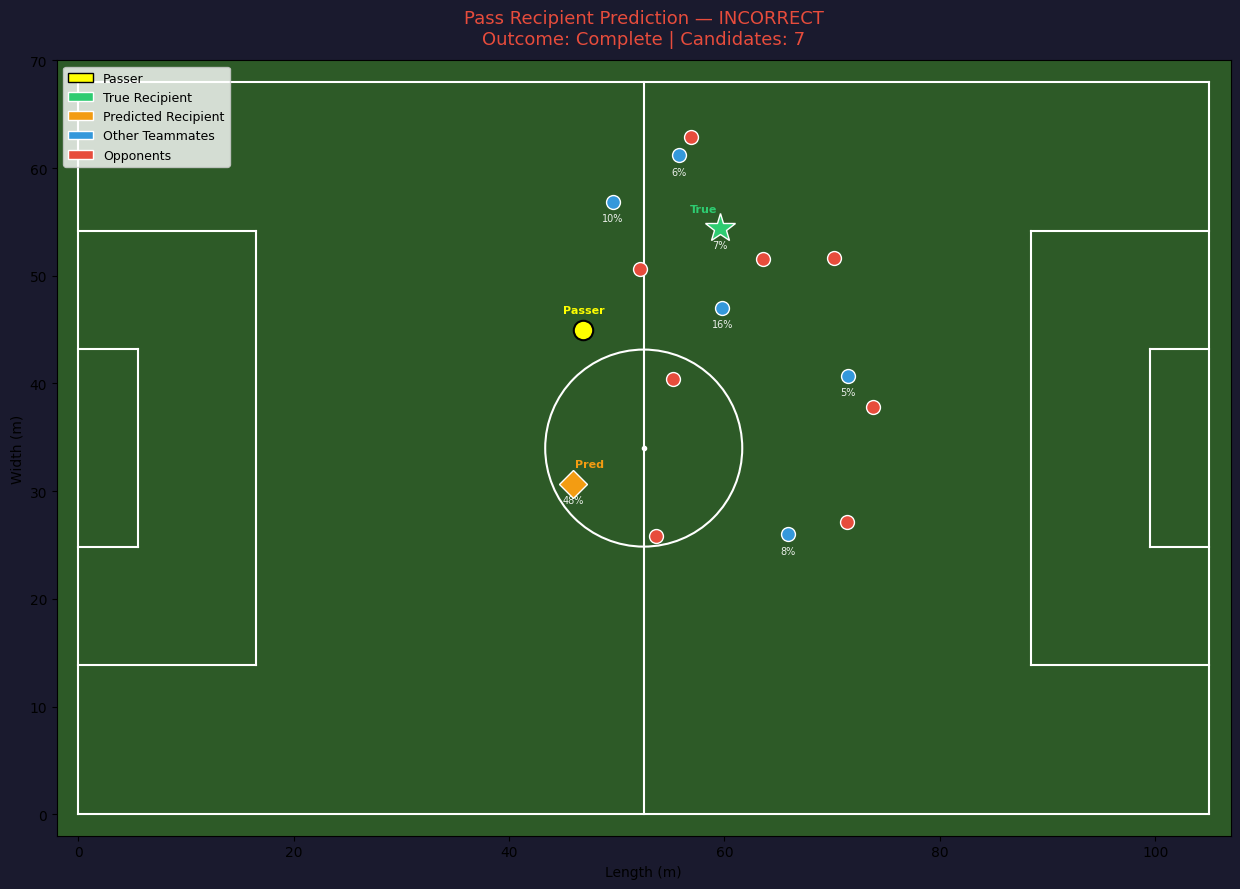

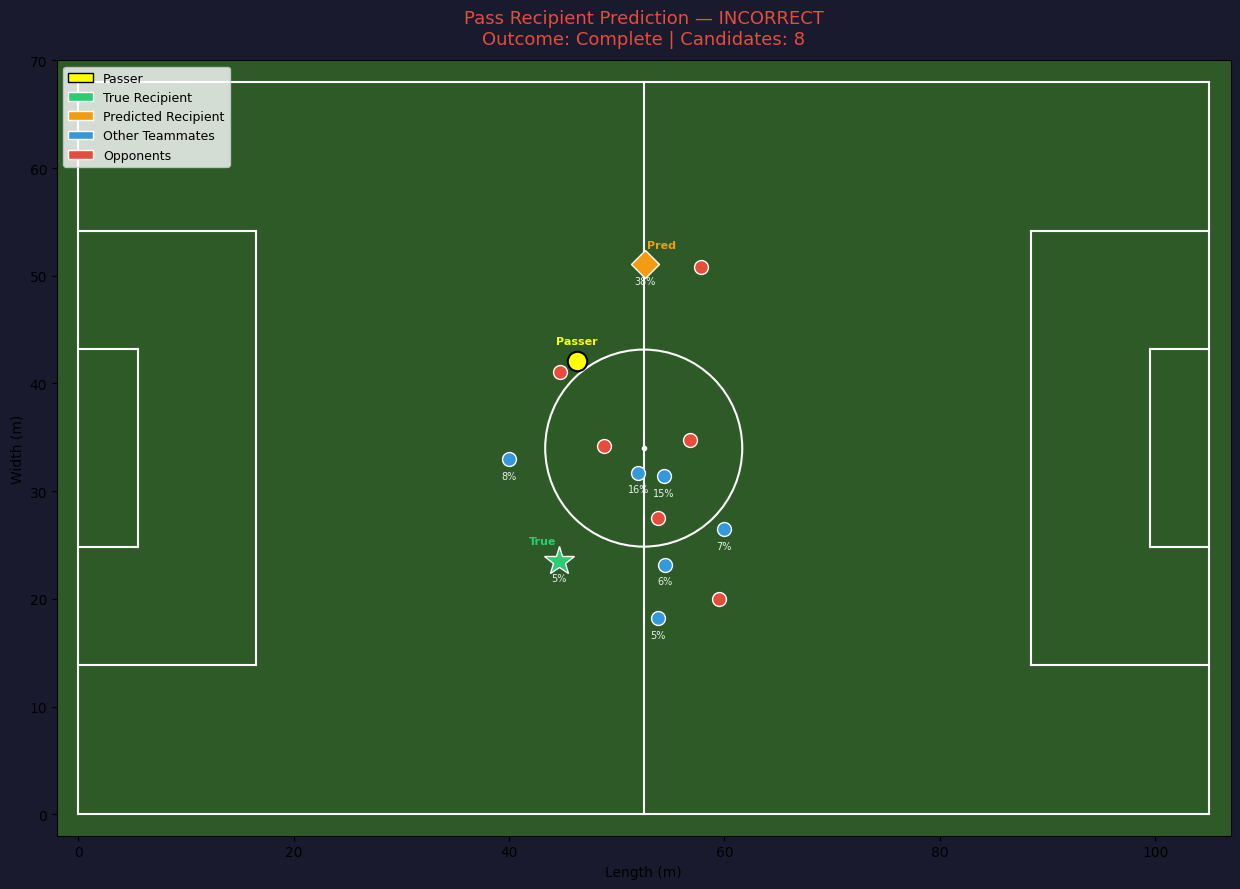

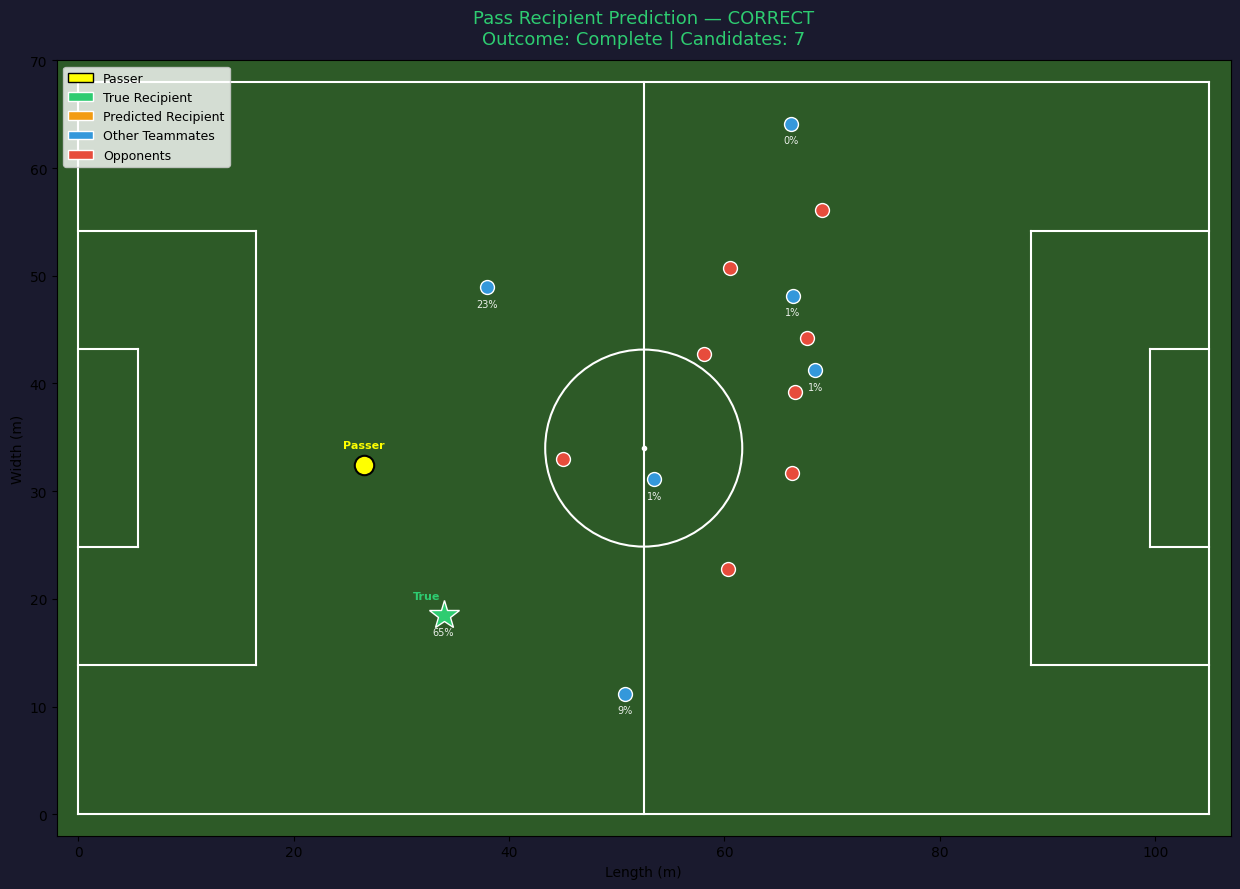

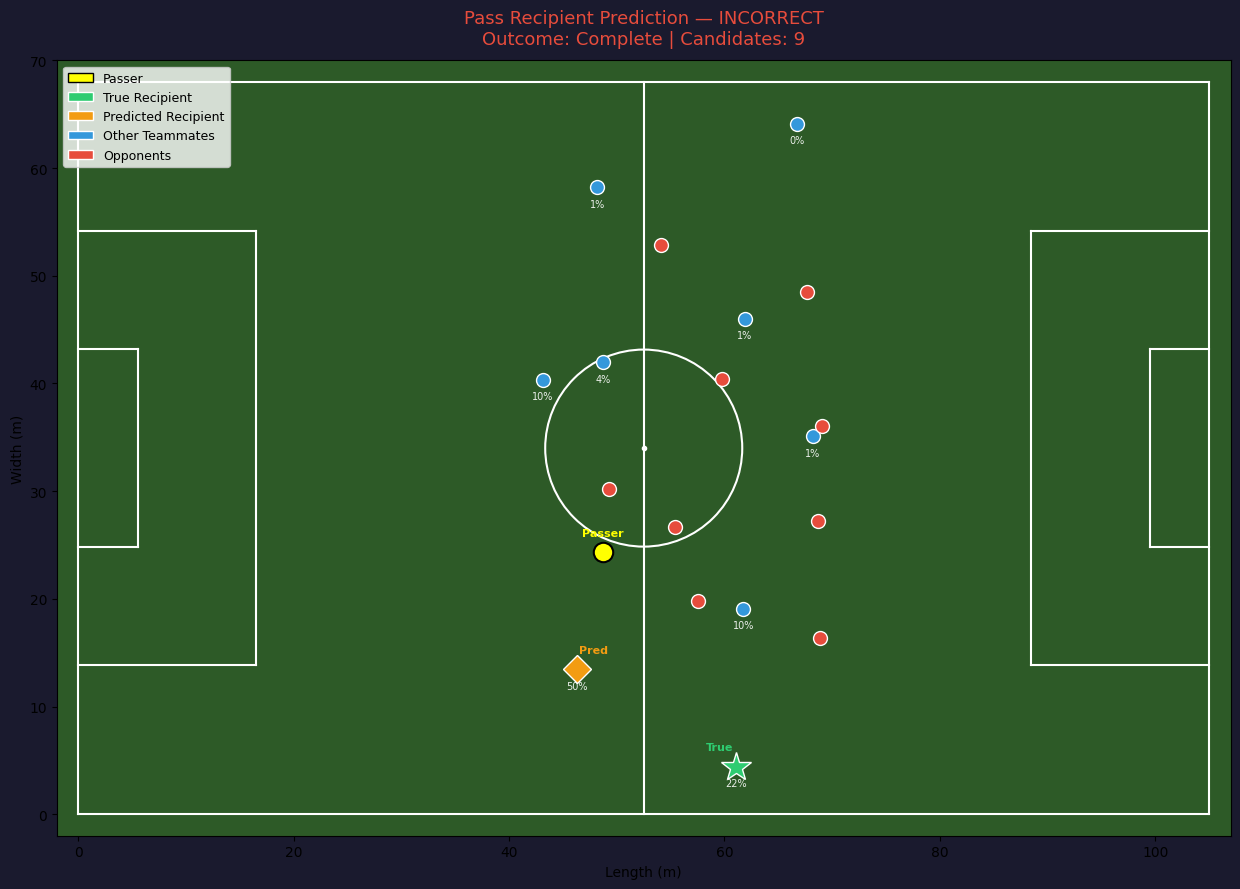

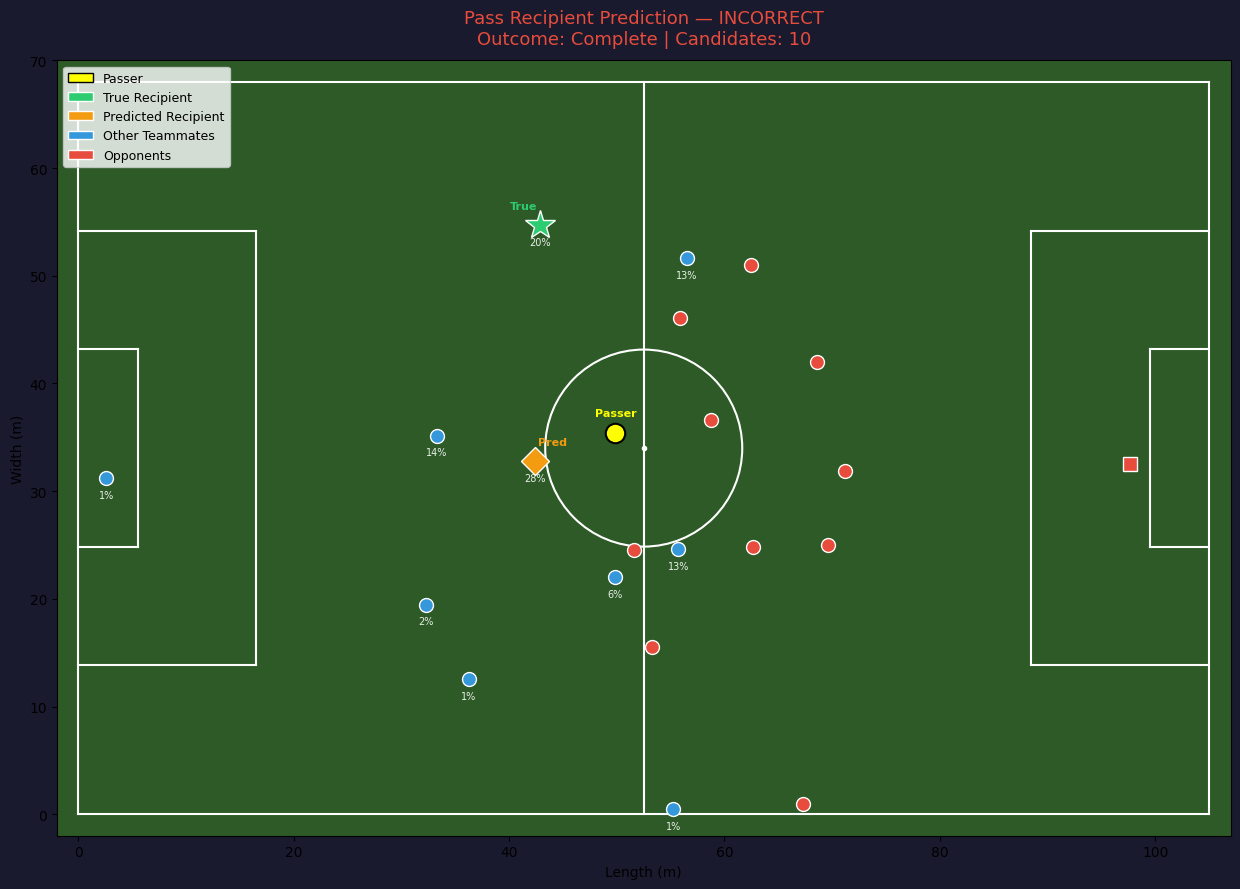

In [27]:
def visualize_prediction(graph: Data, model: nn.Module):
    """Visualize model prediction for a single pass graph on a meter-scale pitch."""
    model.eval()
    with torch.no_grad():
        graph_dev = graph.to(device)
        scores = model(graph_dev.x, graph_dev.edge_index).cpu()

    candidate_mask = graph.candidate_mask
    candidate_indices = torch.where(candidate_mask)[0]
    candidate_scores = scores[candidate_mask]
    probs = F.softmax(candidate_scores, dim=0).numpy()
    ranked = candidate_scores.argsort(descending=True)

    predicted_idx = candidate_indices[ranked[0]].item()
    true_idx = graph.y.item()
    correct = predicted_idx == true_idx

    fig, ax = plt.subplots(figsize=(14, 9))
    draw_pitch(ax)

    features = graph.x.numpy()
    for i in range(features.shape[0]):
        # Convert normalized [0,1] back to meters
        px_m = features[i, 0] * FIFA_PITCH_LENGTH
        py_m = features[i, 1] * FIFA_PITCH_WIDTH
        is_teammate = features[i, 2] > 0.5
        is_actor = features[i, 3] > 0.5
        is_keeper = features[i, 4] > 0.5

        if is_actor:
            ax.plot(px_m, py_m, 'o', color='yellow', ms=14, zorder=5,
                    markeredgecolor='black', markeredgewidth=1.5)
            ax.annotate('Passer', (px_m, py_m), textcoords="offset points",
                        xytext=(0, 12), ha='center', fontsize=8, color='yellow', fontweight='bold')
        elif i == true_idx:
            ax.plot(px_m, py_m, '*', color='#2ecc71', ms=22, zorder=6,
                    markeredgecolor='white', markeredgewidth=1)
            ax.annotate('True', (px_m, py_m), textcoords="offset points",
                        xytext=(-12, 12), ha='center', fontsize=8, color='#2ecc71', fontweight='bold')
        elif i == predicted_idx:
            ax.plot(px_m, py_m, 'D', color='#f39c12', ms=14, zorder=6,
                    markeredgecolor='white', markeredgewidth=1)
            ax.annotate('Pred', (px_m, py_m), textcoords="offset points",
                        xytext=(12, 12), ha='center', fontsize=8, color='#f39c12', fontweight='bold')
        elif is_teammate:
            marker = 's' if is_keeper else 'o'
            ax.plot(px_m, py_m, marker, color='#3498db', ms=10, zorder=4,
                    markeredgecolor='white', markeredgewidth=1)
        else:
            marker = 's' if is_keeper else 'o'
            ax.plot(px_m, py_m, marker, color='#e74c3c', ms=10, zorder=4,
                    markeredgecolor='white', markeredgewidth=1)

        # Show probability for candidates
        if candidate_mask[i]:
            cand_local = (candidate_indices == i).nonzero(as_tuple=True)[0][0].item()
            prob = probs[cand_local]
            ax.annotate(f'{prob:.0%}', (px_m, py_m), textcoords="offset points",
                        xytext=(0, -14), ha='center', fontsize=7, color='white', alpha=0.9)

    result_text = "CORRECT" if correct else "INCORRECT"
    result_color = "#2ecc71" if correct else "#e74c3c"
    ax.set_title(f"Pass Recipient Prediction — {result_text}\n"
                 f"Outcome: {graph.pass_outcome} | Candidates: {candidate_mask.sum().item()}",
                 fontsize=13, color=result_color, pad=12)

    legend_elements = [
        mpatches.Patch(facecolor='yellow', edgecolor='black', label='Passer'),
        mpatches.Patch(facecolor='#2ecc71', edgecolor='white', label='True Recipient'),
        mpatches.Patch(facecolor='#f39c12', edgecolor='white', label='Predicted Recipient'),
        mpatches.Patch(facecolor='#3498db', edgecolor='white', label='Other Teammates'),
        mpatches.Patch(facecolor='#e74c3c', edgecolor='white', label='Opponents'),
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=9)
    fig.patch.set_facecolor('#1a1a2e')
    plt.tight_layout()
    plt.show()


# Show a few test set predictions
np.random.seed(42)
sample_indices = np.random.choice(len(test_graphs), size=min(6, len(test_graphs)), replace=False)

for idx in sample_indices:
    visualize_prediction(test_graphs[idx], model)

## 11. Accuracy by Number of Candidates

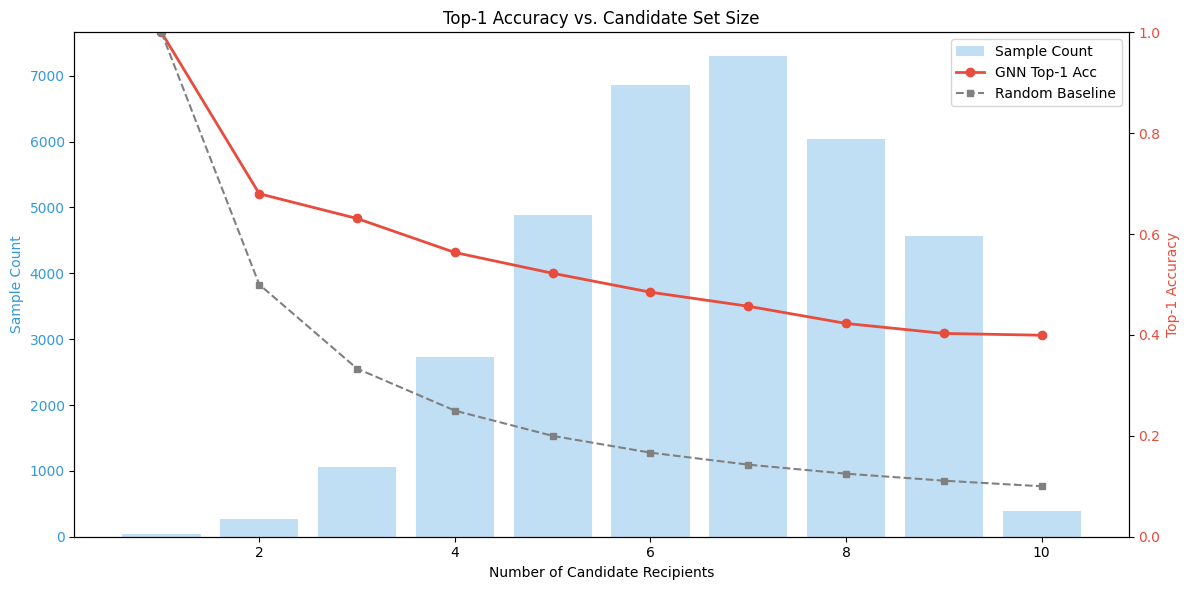

In [28]:
model.eval()
results_by_ncand = defaultdict(lambda: {"correct": 0, "total": 0})

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        scores = model(batch.x, batch.edge_index)
        masked = torch.where(
            batch.candidate_mask, scores,
            torch.tensor(NEG_INF, device=scores.device),
        )
        global_targets = batch.ptr[:-1] + batch.y
        valid = batch.candidate_mask[global_targets]

        for g in range(batch.num_graphs):
            if not valid[g]:
                continue
            start = batch.ptr[g].item()
            end = batch.ptr[g + 1].item()
            predicted_global = start + masked[start:end].argmax().item()
            nc = batch.candidate_mask[start:end].sum().item()
            results_by_ncand[nc]["total"] += 1
            if predicted_global == global_targets[g].item():
                results_by_ncand[nc]["correct"] += 1

nc_sorted = sorted(results_by_ncand.keys())
acc_by_nc = [results_by_ncand[nc]["correct"] / results_by_ncand[nc]["total"] for nc in nc_sorted]
count_by_nc = [results_by_ncand[nc]["total"] for nc in nc_sorted]
random_by_nc = [1.0 / nc for nc in nc_sorted]

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(nc_sorted, count_by_nc, alpha=0.3, color='#3498db', label='Sample Count')
ax1.set_xlabel('Number of Candidate Recipients')
ax1.set_ylabel('Sample Count', color='#3498db')
ax1.tick_params(axis='y', labelcolor='#3498db')

ax2 = ax1.twinx()
ax2.plot(nc_sorted, acc_by_nc, 'o-', color='#e74c3c', label='GNN Top-1 Acc', linewidth=2, markersize=6)
ax2.plot(nc_sorted, random_by_nc, 's--', color='gray', label='Random Baseline', linewidth=1.5, markersize=5)
ax2.set_ylabel('Top-1 Accuracy', color='#e74c3c')
ax2.tick_params(axis='y', labelcolor='#e74c3c')
ax2.set_ylim(0, 1)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

ax1.set_title('Top-1 Accuracy vs. Candidate Set Size')
plt.tight_layout()
plt.show()